# Analisis de datos B2B

In [2]:
import sys
import pandas as pd
import numpy as np
import nltk


import re
import nltk
from joblib import dump, load
import matplotlib.pyplot as plt
pd.options.display.max_colwidth=200
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler  # Asegúrate de importar StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score




import scipy.stats as stats
import seaborn as sns; sns.set()  # for plot styling

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import MinMaxScaler

from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D # for 3D plots
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, GridSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
from sklearn.metrics import mean_squared_error as mse, r2_score, mean_absolute_error as mae


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import tree


from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

# Para búsqueda de hiperparámetros
from sklearn.model_selection import GridSearchCV
# Para la validación cruzada
from sklearn.model_selection import KFold

# Metricas
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# q-q plots
import scipy.stats as stats


## Carga de datos

In [3]:
pd = pd.read_csv('base_3_transaccional_b2b.txt', sep = '\t')



In [4]:
df_B2B = pd.copy()

Se cargan los datos de la empresa de datos B2B en un dataframe de pandas. Se realiza una copia del dataframe para evitar modificar el original. 

A continuación se realiza el analisis y entendimiento de los datos de la base B2B

## 1. Entendimiento y Perfilamiento de datos

In [27]:
df_B2B.shape

(25866, 10)

In [28]:
df_B2B.dtypes

fecha_factura                                 object
id_b2b                                        object
municipio                                     object
zona                                          object
categoria_b2b_macro                           object
categoria_b2b                                 object
subcategoria_b2b                              object
producto                                      object
valor_total                                  float64
alineación con portafolio estratégico b2b    float64
dtype: object

In [29]:
df_B2B.head(5)

,fecha_factura,id_b2b,municipio,zona,categoria_b2b_macro,categoria_b2b,subcategoria_b2b,producto,valor_total,alineación con portafolio estratégico b2b
0,2007-01-03,B2B_01,MADRID,CUNDINAMARCA,cat_b2b_macro_1,cat_b2b_1,sub_b2b_1,Producto_1,1819.931192,0.000216
1,2007-01-03,B2B_01,MADRID,CUNDINAMARCA,cat_b2b_macro_1,cat_b2b_1,sub_b2b_1,Producto_2,1713.359382,0.000077
2,2007-01-04,B2B_02,VILLA DE LEYVA,BOYACA,cat_b2b_macro_2,cat_b2b_3,sub_b2b_3,Producto_4,208.510406,0.000069
3,2007-01-04,B2B_02,VILLA DE LEYVA,BOYACA,cat_b2b_macro_1,cat_b2b_1,sub_b2b_11,Producto_13,3319.449852,0.000308
4,2007-01-04,B2B_02,VILLA DE LEYVA,BOYACA,cat_b2b_macro_1,cat_b2b_1,sub_b2b_12,Producto_14,4945.685288,0.000110


Se evidencia que la fecha se estaba almacenando como un objeto, por lo que se convierte a un dato de tipo datetime.

In [35]:
df_B2B['fecha_factura'] = pd.to_datetime(
    df_B2B['fecha_factura'].astype(str).str.strip(),
    format='%Y-%m-%d',
    errors='coerce'
)


In [36]:
df_B2B

,fecha_factura,id_b2b,municipio,zona,categoria_b2b_macro,categoria_b2b,subcategoria_b2b,producto,valor_total,alineación con portafolio estratégico b2b
0,2007-01-03,B2B_01,MADRID,CUNDINAMARCA,cat_b2b_macro_1,cat_b2b_1,sub_b2b_1,Producto_1,1819.931192,0.000216
1,2007-01-03,B2B_01,MADRID,CUNDINAMARCA,cat_b2b_macro_1,cat_b2b_1,sub_b2b_1,Producto_2,1713.359382,0.000077
2,2007-01-04,B2B_02,VILLA DE LEYVA,BOYACA,cat_b2b_macro_2,cat_b2b_3,sub_b2b_3,Producto_4,208.510406,0.000069
3,2007-01-04,B2B_02,VILLA DE LEYVA,BOYACA,cat_b2b_macro_1,cat_b2b_1,sub_b2b_11,Producto_13,3319.449852,0.000308
4,2007-01-04,B2B_02,VILLA DE LEYVA,BOYACA,cat_b2b_macro_1,cat_b2b_1,sub_b2b_12,Producto_14,4945.685288,0.000110
...,...,...,...,...,...,...,...,...,...,...
25861,2010-02-18,B2B_05,FUSAGASUGA,CUNDINAMARCA,cat_b2b_macro_11,cat_b2b_14,sub_b2b_23,Producto_66,303.853648,0.000654
25862,2010-02-18,B2B_05,FUSAGASUGA,CUNDINAMARCA,cat_b2b_macro_14,cat_b2b_14,sub_b2b_23,Producto_809,85.641002,0.000654
25863,2010-02-18,B2B_05,FUSAGASUGA,CUNDINAMARCA,cat_b2b_macro_15,cat_b2b_15,sub_b2b_24,Producto_1049,75.615354,0.000654
25864,2010-02-18,B2B_06,TUNJA,BOYACA,cat_b2b_macro_1,cat_b2b_1,sub_b2b_43,Producto_1255,2640.812674,0.000654


In [40]:
column_titles = df_B2B.columns.tolist()
column_titles

['fecha_factura',
 'id_b2b',
 'municipio',
 'zona',
 'categoria_b2b_macro',
 'categoria_b2b',
 'subcategoria_b2b',
 'producto',
 'valor_total',
 'alineación con portafolio estratégico b2b']

In [42]:
# Para categorizar las variables en su tipo de dato
categorical_cols = df_B2B.select_dtypes(include=["object"]).columns
numeric_cols = df_B2B.select_dtypes(include=["number"]).columns
datetime_cols = df_B2B.select_dtypes(include=["datetime"]).columns

# Imprimir las variables categóricas
print("Variables categóricas:")
print(", ".join(categorical_cols))

# Imprimir las variables numéricas
print("\nVariables numéricas:")
print(", ".join(numeric_cols))

# Imprimir las variables de fecha
print("\nVariables de fecha:")
print(", ".join(datetime_cols))

Variables categóricas:
id_b2b, municipio, zona, categoria_b2b_macro, categoria_b2b, subcategoria_b2b, producto

Variables numéricas:
valor_total, alineación con portafolio estratégico b2b

Variables de fecha:
fecha_factura


## 1.1. Atributos numéricos, categoricos y de Fecha

### 1.1.1 Atributos numéricos

In [43]:
atributosNum = df_B2B.select_dtypes(include=[np.number]).columns


In [44]:
df_B2B[atributosNum].describe()

,valor_total,alineación con portafolio estratégico b2b
count,25866.000000,25866.000000
mean,1535.979362,0.000294
std,2257.971976,0.000155
min,5.219884,-0.008032
25%,168.112753,0.000225
50%,525.062748,0.000292
75%,2191.560508,0.000371
max,68751.946040,0.000654


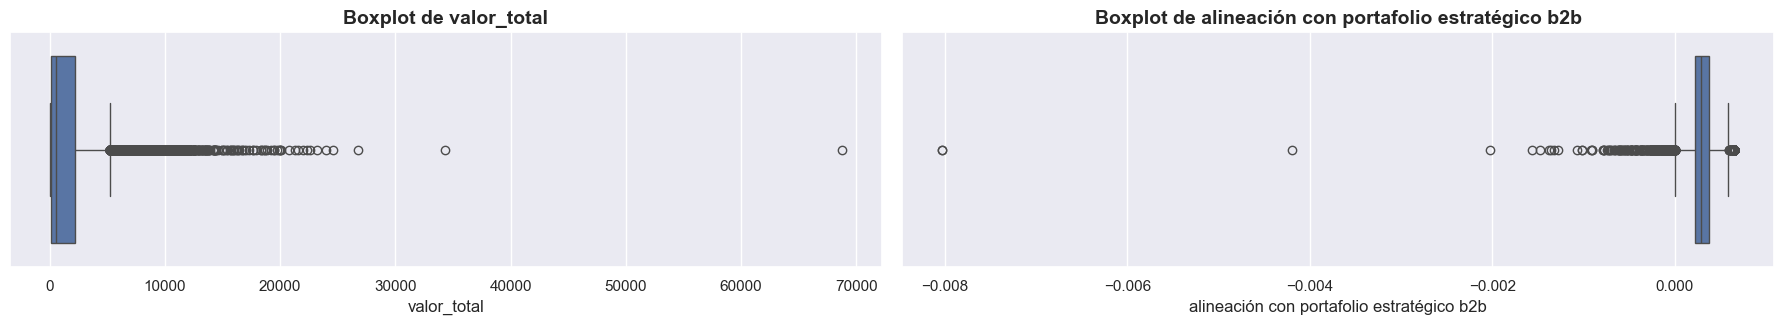

In [45]:
# Se puede graficar el histograma de cada atributo numérico para ver como se distribuyen
plt.figure(figsize=(18, 24))
for i, col in enumerate(atributosNum, 1):
    plt.subplot(8, 2, i)
    sns.boxplot(x=df_B2B[col])
    plt.title(f'Boxplot de {col}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [46]:
def plot_outliers(df, column):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Boxplot
    sns.boxplot(y=df[column], ax=axes[0], color='lightblue')
    axes[0].set_title(f'Boxplot of {column}')

    # Histogram
    sns.histplot(df[column], bins=30, kde=True, ax=axes[1], color='lightblue')
    axes[1].set_title(f'Histogram of {column}')

    plt.tight_layout()
    plt.show()
def Scatter_distribution(df, vars_to_plot):
    num_vars = len(vars_to_plot)
    rows = cols = int(num_vars ** 0.5) + 1  # Create a near-square grid
    fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
    axes = axes.flatten()

    for i, var in enumerate(vars_to_plot):
        axes[i].scatter(df.index, df[var], alpha=0.5, s=10)
        axes[i].set_title(var)
        axes[i].set_ylabel(var)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


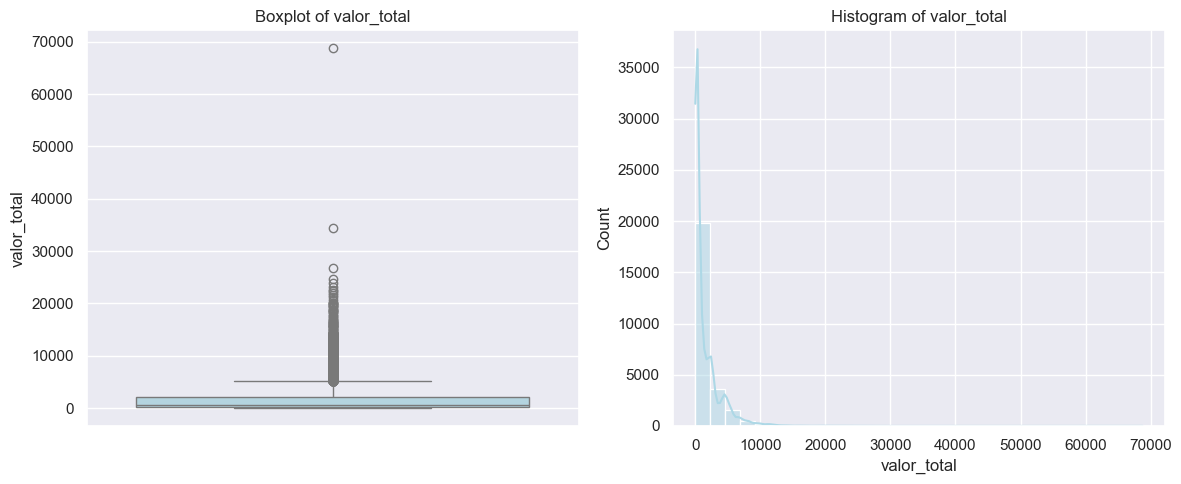

In [48]:
plot_outliers(df_B2B, 'valor_total')

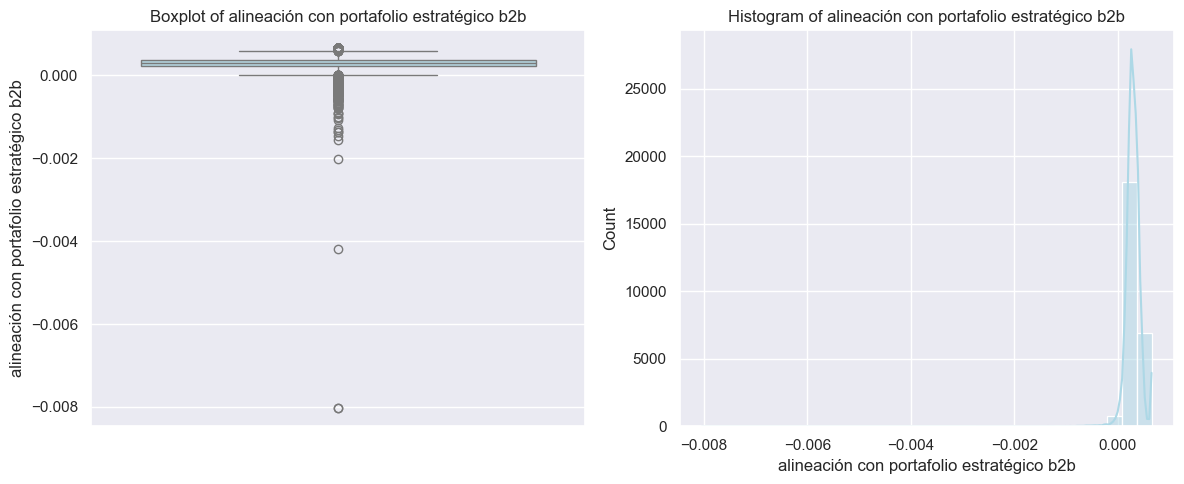

In [49]:
plot_outliers(df_B2B, 'alineación con portafolio estratégico b2b')

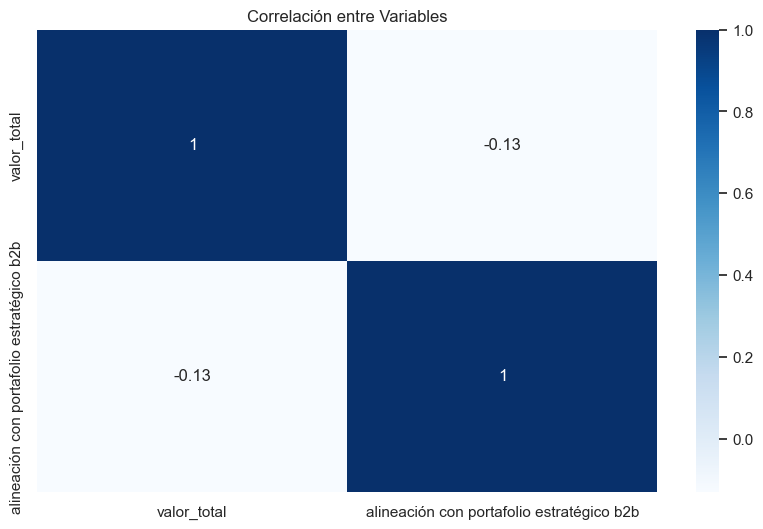

In [50]:
df_numeric = df_B2B.select_dtypes(include=[np.number])
# Calcular la matriz de correlación
correlation_matrix = df_numeric.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap = "Blues")

# Mostrar el gráfico
plt.title("Correlación entre Variables")
plt.show()

#### Análisis de distribución de variables numércas significativas

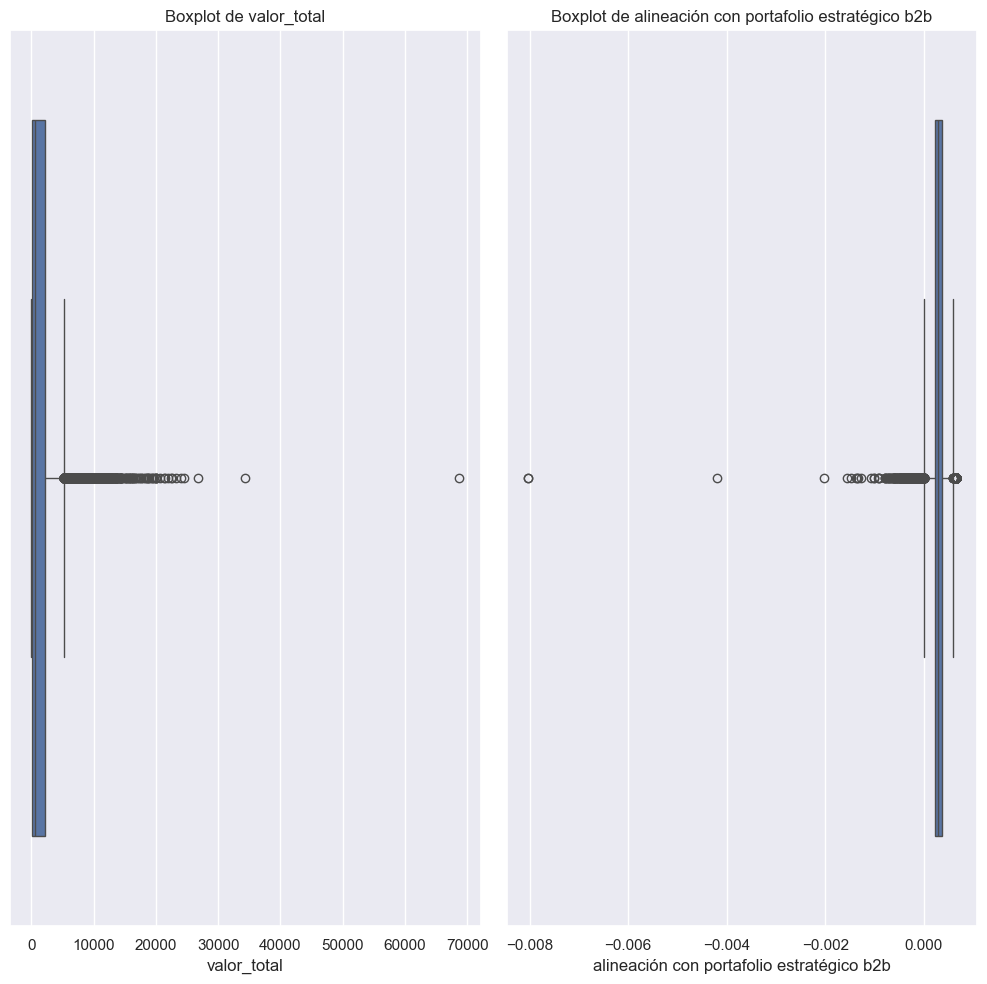

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numeric_data = df_B2B.select_dtypes(include=[float, int])

# Configurar el tamaño de los gráficos
plt.figure(figsize=(15, 10))
num_vars = len(numeric_data.columns)
n_cols = 3 
n_rows = int(np.ceil(num_vars / n_cols))  

# Crear un boxplot para cada variable numérica
for i, column in enumerate(numeric_data.columns, 1):
    plt.subplot(n_rows, n_cols, i)  
    sns.boxplot(data=numeric_data, x=column)
    plt.title(f'Boxplot de {column}')
    plt.tight_layout()

plt.show()

Si se quiere ver sin **valores atipicos**

Valor total

In [67]:
# Valor Máximo = Q3 + 1.5 × (Q3 - Q1)
q1 = df_B2B["valor_total"].quantile(0.25)
q3 = df_B2B["valor_total"].quantile(0.75)
umbral = q3 + (q3 - q1) * 1.5
umbral

5226.732139749999

In [68]:
cantidadRSMenoresAlUmbral = (df_B2B["valor_total"] < umbral).sum()
porcentajeRSMenoresAlUmbral = 100 * cantidadRSMenoresAlUmbral / len(df_B2B['valor_total'])

print(f'Cantidad de duraciones menores a {umbral}: {cantidadRSMenoresAlUmbral}')
print(f'Porcentaje de duraciones menores a {umbral}: {porcentajeRSMenoresAlUmbral:.2f}%')

Cantidad de duraciones menores a 5226.732139749999: 24143
Porcentaje de duraciones menores a 5226.732139749999: 93.34%


alineación con portafolio estratégico b2b

In [63]:
# Valor Máximo = Q3 + 1.5 × (Q3 - Q1)
q1 = df_B2B["alineación con portafolio estratégico b2b"].quantile(0.25)
q3 = df_B2B["alineación con portafolio estratégico b2b"].quantile(0.75)
umbral = q3 + (q3 - q1) * 1.5
umbral_min = q1 - 1.5 * (q3 - q1)
umbral

0.0005891273644042126

In [65]:
cantidadRSMayoresAlUmbral = (df_B2B["alineación con portafolio estratégico b2b"] > umbral_min).sum()
porcentajeRSMayoresAlUmbral = 100 * cantidadRSMayoresAlUmbral / len(df_B2B["alineación con portafolio estratégico b2b"])

print(f'Cantidad de duraciones mayores a {umbral}: {cantidadRSMayoresAlUmbral}')
print(f'Porcentaje de duraciones mayores a {umbral}: {porcentajeRSMayoresAlUmbral:.2f}%')

Cantidad de duraciones mayores a 0.0005891273644042126: 25466
Porcentaje de duraciones mayores a 0.0005891273644042126: 98.45%


### 1.1.2 Atributos categoricos

In [71]:
categorical_cols

Index(['id_b2b', 'municipio', 'zona', 'categoria_b2b_macro', 'categoria_b2b',
       'subcategoria_b2b', 'producto'],
      dtype='object')

In [72]:
# Con esta tablita puedo ver que porcentaje representa cada clase, si se desea se puede cambiar la columna (tocaria una a una)
atributosCategoricos = df_B2B['municipio'].value_counts()
pd.DataFrame({'Valores de Grupo': atributosCategoricos.index, 'Conteo': atributosCategoricos.values, 'Porcentaje (%)': atributosCategoricos.values * 100 / atributosCategoricos.values.sum()}).sort_values(by='Conteo', ascending=False)

,Valores de Grupo,Conteo,Porcentaje (%)
0,FUSAGASUGA,16263,62.874043
1,VILLA DE LEYVA,6583,25.450398
2,MADRID,2142,8.281141
3,TUNJA,479,1.851852
4,#,399,1.542566


In [73]:
# Con esta tablita puedo ver que porcentaje representa cada clase, si se desea se puede cambiar la columna (tocaria una a una)
atributosCategoricos = df_B2B['categoria_b2b_macro'].value_counts()
pd.DataFrame({'Valores de Grupo': atributosCategoricos.index, 'Conteo': atributosCategoricos.values, 'Porcentaje (%)': atributosCategoricos.values * 100 / atributosCategoricos.values.sum()}).sort_values(by='Conteo', ascending=False)

,Valores de Grupo,Conteo,Porcentaje (%)
0,cat_b2b_macro_1,5768,22.299544
1,cat_b2b_macro_3,5163,19.960566
2,cat_b2b_macro_5,3489,13.488750
3,cat_b2b_macro_2,3470,13.415294
4,cat_b2b_macro_4,2397,9.266991
5,cat_b2b_macro_9,1756,6.788835
6,cat_b2b_macro_10,901,3.483337
7,cat_b2b_macro_8,835,3.228176
8,cat_b2b_macro_6,777,3.003943
9,cat_b2b_macro_11,330,1.275806


In [74]:
# Con esta tablita puedo ver que porcentaje representa cada clase, si se desea se puede cambiar la columna (tocaria una a una)
atributosCategoricos = df_B2B['categoria_b2b'].value_counts()
pd.DataFrame({'Valores de Grupo': atributosCategoricos.index, 'Conteo': atributosCategoricos.values, 'Porcentaje (%)': atributosCategoricos.values * 100 / atributosCategoricos.values.sum()}).sort_values(by='Conteo', ascending=False)

,Valores de Grupo,Conteo,Porcentaje (%)
0,cat_b2b_1,5413,20.927086
1,cat_b2b_14,2080,8.041444
2,cat_b2b_7,1841,7.117451
3,cat_b2b_15,1821,7.040130
4,cat_b2b_11,1701,6.576200
5,cat_b2b_19,1385,5.354519
6,cat_b2b_6,940,3.634114
7,cat_b2b_4,903,3.491069
8,cat_b2b_2,792,3.061935
9,cat_b2b_32,657,2.540014


In [93]:
# Con esta tablita puedo ver que porcentaje representa cada clase, si se desea se puede cambiar la columna (tocaria una a una)
atributosCategoricos = df_B2B['subcategoria_b2b'].value_counts()
pd.DataFrame({'Valores de Grupo': atributosCategoricos.index, 'Conteo': atributosCategoricos.values, 'Porcentaje (%)': atributosCategoricos.values * 100 / atributosCategoricos.values.sum()}).sort_values(by='Conteo', ascending=False)

,Valores de Grupo,Conteo,Porcentaje (%)
0,sub_b2b_23,4283,16.558416
1,sub_b2b_1,2090,8.080105
2,sub_b2b_12,1147,4.434393
3,sub_b2b_11,988,3.819686
4,sub_b2b_15,940,3.634114
...,...,...,...
132,sub_b2b_121,1,0.003866
131,sub_b2b_78,1,0.003866
129,sub_b2b_134,1,0.003866
128,sub_b2b_137,1,0.003866


In [78]:
# Con esta tablita puedo ver que porcentaje representa cada clase, si se desea se puede cambiar la columna (tocaria una a una)
atributosCategoricos = df_B2B['producto'].value_counts()
pd.DataFrame({'Valores de Grupo': atributosCategoricos.index, 'Conteo': atributosCategoricos.values, 'Porcentaje (%)': atributosCategoricos.values * 100 / atributosCategoricos.values.sum()}).sort_values(by='Conteo', ascending=False)

,Valores de Grupo,Conteo,Porcentaje (%)
0,Producto_377,288,1.113431
1,Producto_167,201,0.777082
2,Producto_55,170,0.657233
3,Producto_54,160,0.618573
4,Producto_56,160,0.618573
...,...,...,...
2089,Producto_2564,1,0.003866
2090,Producto_2615,1,0.003866
2091,Producto_2510,1,0.003866
2092,Producto_2509,1,0.003866


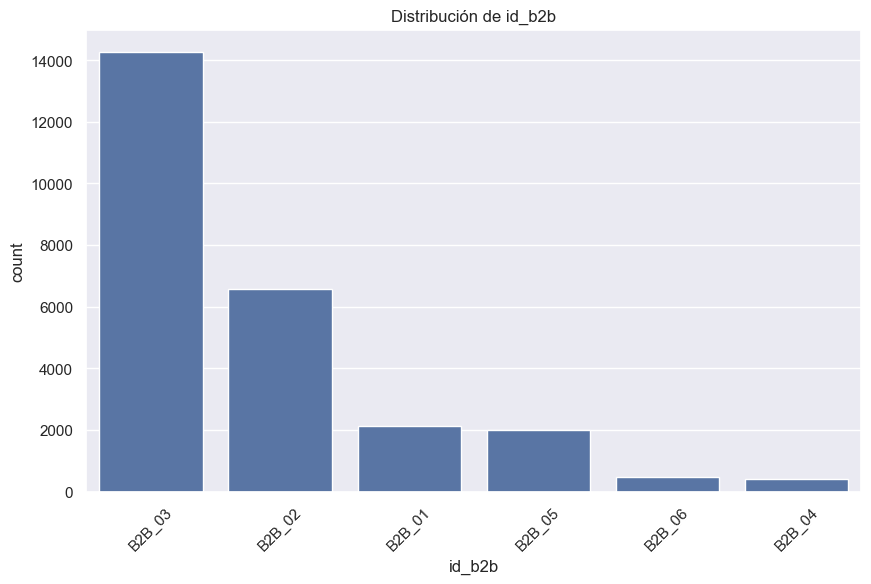

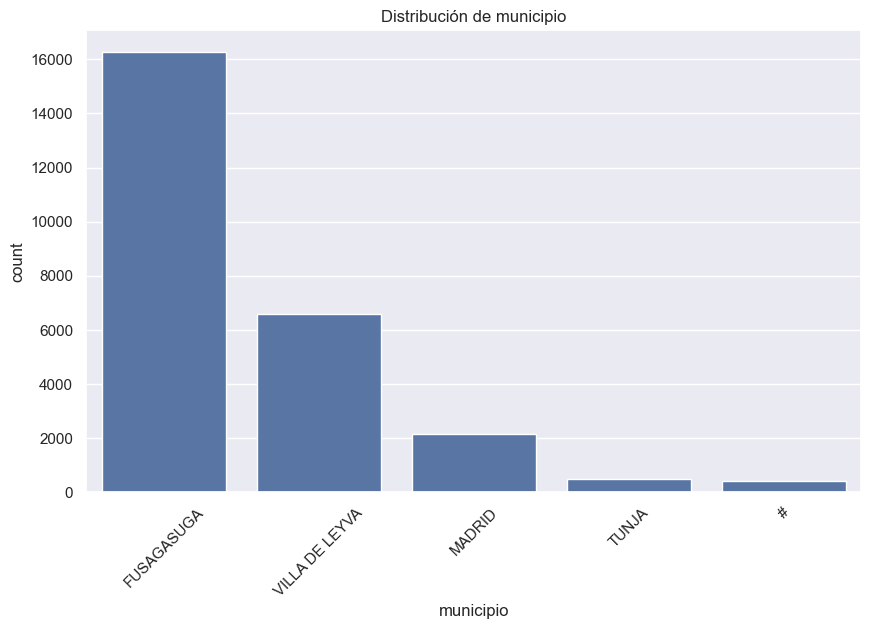

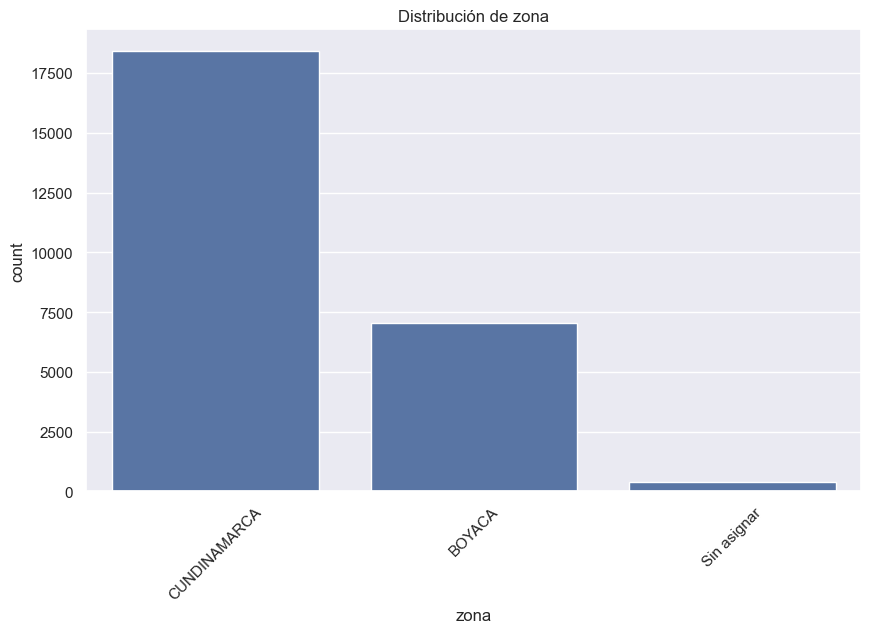

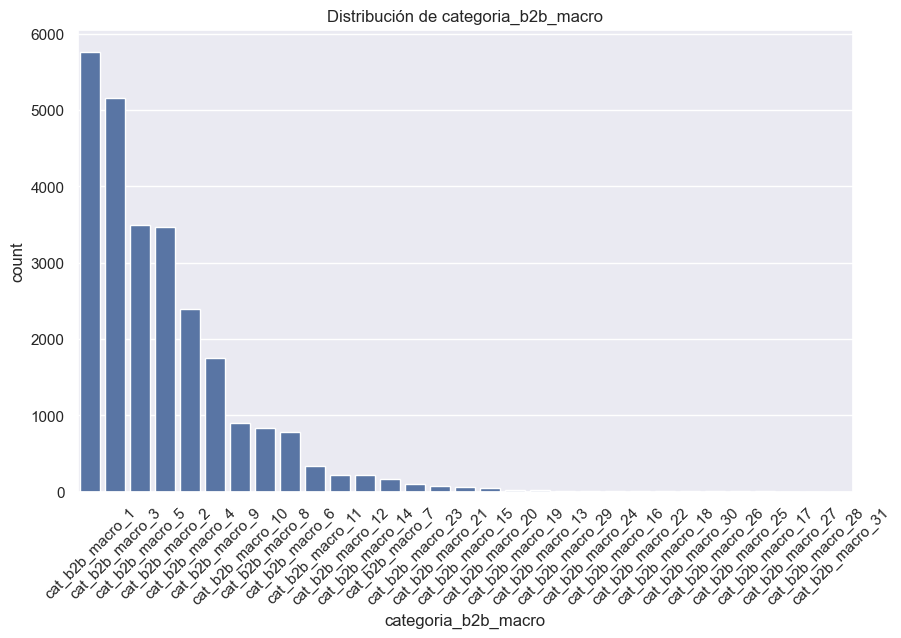

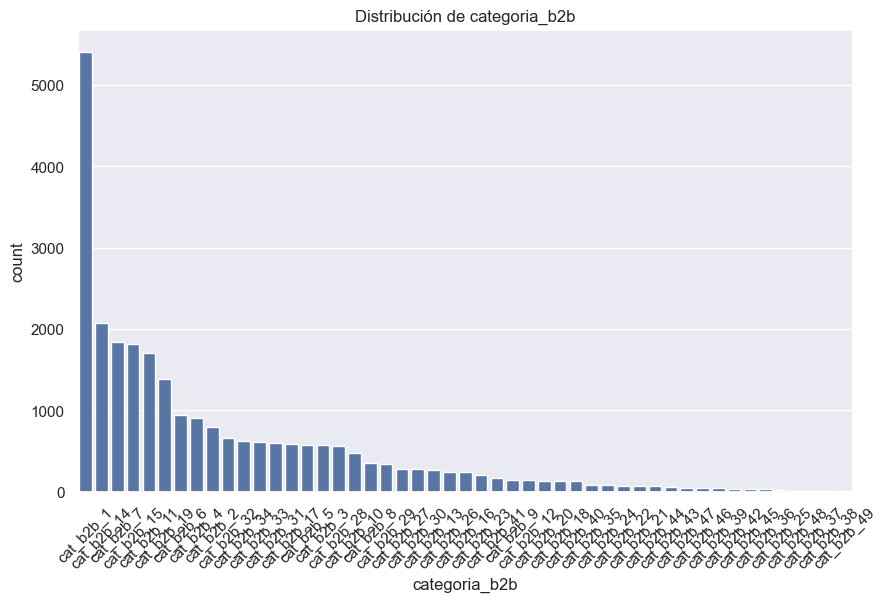

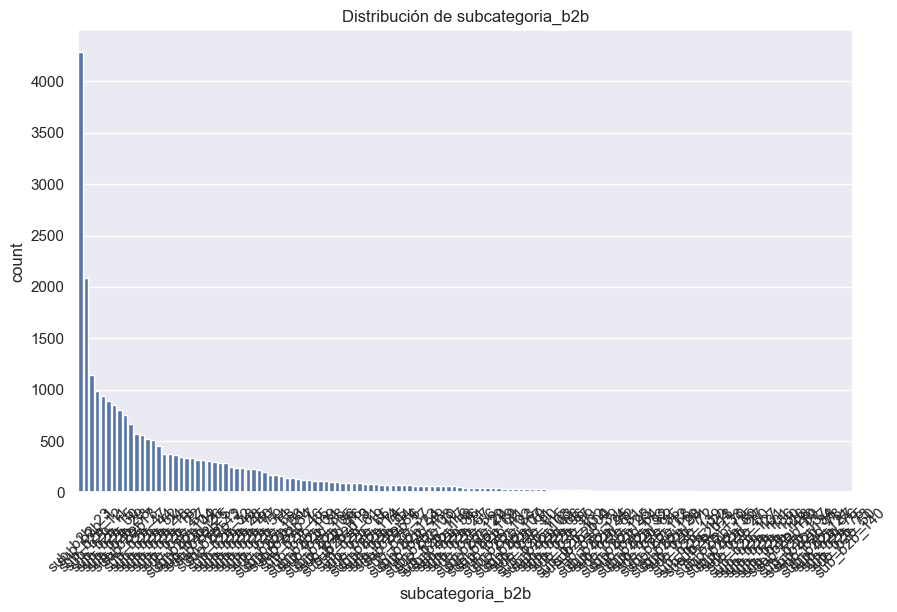

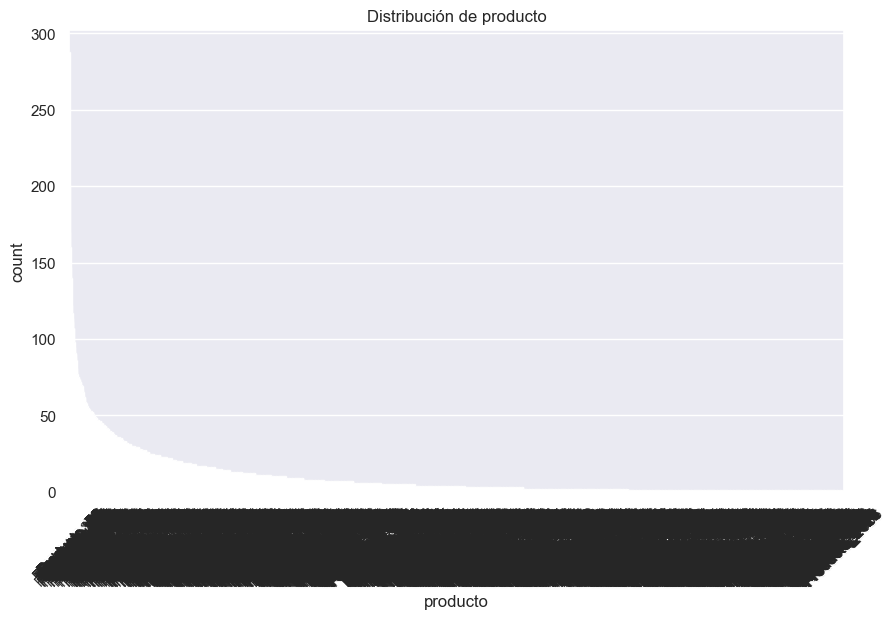

In [83]:
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_B2B, x=col, order=df_B2B[col].value_counts().index)
    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=45)
    plt.show()

### 1.1.3 Atributos temporales

In [94]:
# Con esta tablita puedo ver que porcentaje representa cada clase, si se desea se puede cambiar la columna (tocaria una a una)
atributosTemporales = df_B2B['fecha_factura'].value_counts()
pd.DataFrame({'Valores de Grupo': atributosTemporales.index, 'Conteo': atributosTemporales.values, 'Porcentaje (%)': atributosTemporales.values * 100 / atributosTemporales.values.sum()}).sort_values(by='Conteo', ascending=False)

,Valores de Grupo,Conteo,Porcentaje (%)
0,2008-04-24,148,0.572180
1,2007-12-06,133,0.514189
2,2010-01-30,128,0.494858
3,2009-09-27,124,0.479394
4,2010-01-22,118,0.456197
...,...,...,...
1012,2008-06-14,1,0.003866
1011,2009-08-25,1,0.003866
1010,2008-07-09,1,0.003866
1009,2007-01-09,1,0.003866


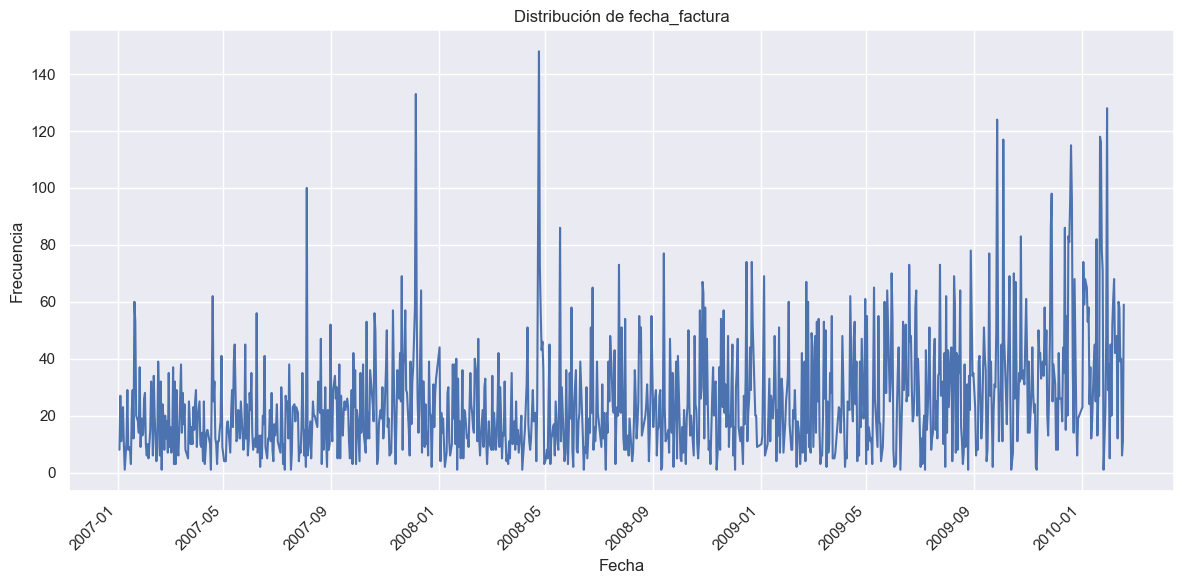

In [95]:
plt.figure(figsize=(12, 6))
df_B2B['fecha_factura'].value_counts().sort_index().plot(kind='line')
plt.title('Distribución de fecha_factura')
plt.xlabel('Fecha')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 1.2. Análisis de calidad de datos

### 1.2.1 Análisis de completitud

In [84]:
# Op1 Se ven el numero de valores nulos
porcentajeIncompletitudAtributo =  (100 * df_B2B.isnull().sum() / df_B2B.shape[0]).sort_values(ascending=False)
pd.DataFrame({
    "Atributo": porcentajeIncompletitudAtributo.index,
    "Completitud (%)": 100 - porcentajeIncompletitudAtributo.values,
    "Incompletitud (%)": porcentajeIncompletitudAtributo.values,
    "Numero de registros duplicados": porcentajeIncompletitudAtributo.values * df_B2B.shape[0] / 100
})

,Atributo,Completitud (%),Incompletitud (%),Numero de registros duplicados
0,fecha_factura,100.0,0.0,0.0
1,id_b2b,100.0,0.0,0.0
2,municipio,100.0,0.0,0.0
3,zona,100.0,0.0,0.0
4,categoria_b2b_macro,100.0,0.0,0.0
5,categoria_b2b,100.0,0.0,0.0
6,subcategoria_b2b,100.0,0.0,0.0
7,producto,100.0,0.0,0.0
8,valor_total,100.0,0.0,0.0
9,alineación con portafolio estratégico b2b,100.0,0.0,0.0


Se evidencia que los datos estan completos!

### 1.2.2 Análisis de Unicidad

In [86]:
# Duplicados
registrosDuplicados = df_B2B.duplicated()
totalDuplicados = registrosDuplicados.sum()
totalRegistros = df_B2B.shape[0]
porcentajeDuplicados = 100.0 * totalDuplicados / totalRegistros
print(f"Se cuenta con {totalDuplicados} registros duplicados ({porcentajeDuplicados:.2f}%)")


Se cuenta con 0 registros duplicados (0.00%)


No hay datos duplicados!

### 1.2.3 Análisis de Validez

#### Variables Categoricas

In [87]:
#CONSISTENCIA VARIABLES CATEGÓRICAS
df_B2B[categorical_cols].describe()

,id_b2b,municipio,zona,categoria_b2b_macro,categoria_b2b,subcategoria_b2b,producto
count,25866,25866,25866,25866,25866,25866,25866
unique,6,5,3,31,49,139,2564
top,B2B_03,FUSAGASUGA,CUNDINAMARCA,cat_b2b_macro_1,cat_b2b_1,sub_b2b_23,Producto_377
freq,14282,16263,18405,5768,5413,4283,288


In [89]:
# Eg2: Se indica de los valores categoricos que son las "aceptadas"
categorical_expected = {
    #"race": ["Caucasian", "Asian", "African American", "Hispanic", "Other"],

}

In [90]:
# Verificación de variables categóricas esperadas
for col, expected_values in categorical_expected.items():
    invalid_values = df_B2B[~df_B2B[col].isin(expected_values)][col].unique()
    if len(invalid_values) > 0:
        print(f"\nValores no esperados en {col}: {invalid_values}")
    else:
        print(f"\nTodos los valores en {col} son válidos")

#### Variables Numericas

In [96]:
# Variables con un mínimo específico (en general es que las variables sean positivas)
numeric_minimums = {
    #"F_SALDO": 0,
}

# Variables con un máximo específico (Si no hay maximo se deja vacio)
numeric_maximums = {
    #"F_SALDO": 1,
}

# !!!! DE NO HABER MAX
# numeric_maximums = {}


# Verificar mínimos
for col, min_val in numeric_minimums.items():
    df_B2B[col] = pd.to_numeric(df_B2B[col], errors="coerce")  
    out_of_range = df_B2B[df_B2B[col] < min_val][col]  

    if not out_of_range.empty:
        print(f"\nValores menores a {min_val} en {col}:")
        print(out_of_range.describe())

# Verificar máximos
for col, max_val in numeric_maximums.items():
    df_B2B[col] = pd.to_numeric(df_B2B[col], errors="coerce")  
    out_of_range = df_B2B[df_B2B[col] > max_val][col]  

    if not out_of_range.empty:
        print(f"\nValores mayores a {max_val} en {col}:")
        print(out_of_range.describe())


### 1.2.4 Análisis de consistencia

In [98]:
# Verifica la fecha más antigua y más reciente que tengan sentido
print(df_B2B["fecha_factura"].min(), df_B2B["fecha_factura"].max())

2007-01-03 00:00:00 2010-02-18 00:00:00


In [99]:
#Verificar que esten las clasificaciones adecuadas para el target
pd.DataFrame(df_B2B["municipio"].unique(), columns=["Label unicos"])

,Label unicos
0,MADRID
1,VILLA DE LEYVA
2,FUSAGASUGA
3,#
4,TUNJA


Es necesario preguntar a que hace referencia el #!!!! No tiene mucho sentido en el contexto de municipios de Colombia

In [101]:
#Verificar que esten las clasificaciones adecuadas para el target
pd.DataFrame(df_B2B["zona"].unique(), columns=["Label unicos"])

,Label unicos
0,CUNDINAMARCA
1,BOYACA
2,Sin asignar


In [102]:
#Verificar que esten las clasificaciones adecuadas para el target
pd.DataFrame(df_B2B["categoria_b2b_macro"].unique(), columns=["Label unicos"])

,Label unicos
0,cat_b2b_macro_1
1,cat_b2b_macro_2
2,cat_b2b_macro_4
3,cat_b2b_macro_5
4,cat_b2b_macro_6
5,cat_b2b_macro_7
6,cat_b2b_macro_8
7,cat_b2b_macro_9
8,cat_b2b_macro_10
9,cat_b2b_macro_11


In [103]:
#Verificar que esten las clasificaciones adecuadas para el target
pd.DataFrame(df_B2B["categoria_b2b"].unique(), columns=["Label unicos"])

,Label unicos
0,cat_b2b_1
1,cat_b2b_3
2,cat_b2b_8
3,cat_b2b_2
4,cat_b2b_9
5,cat_b2b_4
6,cat_b2b_10
7,cat_b2b_11
8,cat_b2b_12
9,cat_b2b_13


In [106]:
#Verificar que esten las clasificaciones adecuadas para el target
pd.DataFrame(df_B2B["subcategoria_b2b"].unique(), columns=["Label unicos"])

,Label unicos
0,sub_b2b_1
1,sub_b2b_3
2,sub_b2b_11
3,sub_b2b_12
4,sub_b2b_13
...,...
134,sub_b2b_137
135,sub_b2b_138
136,sub_b2b_139
137,sub_b2b_88


In [105]:
#Verificar que esten las clasificaciones adecuadas para el target
pd.DataFrame(df_B2B["producto"].unique(), columns=["Label unicos"])

,Label unicos
0,Producto_1
1,Producto_2
2,Producto_4
3,Producto_13
4,Producto_14
...,...
2559,Producto_2683
2560,Producto_131
2561,Producto_2684
2562,Producto_2685


# 2. Preparacion de datos

No se realizó la preparación de datos para esta base ya que cumple con todos los requisitos de calidad para ser tratada y manipulada en los modelos

# 3. Selección y Nuevas Variables

### Conteo Nacional Unidades Económicas

In [5]:
import pandas as pd
df_CN = pd.read_excel('Conteo_Nacional.xlsx', sheet_name='UE')

In [6]:
df_CN.head(1)

,Departamento,Código Municipio,Municipio,Total de unidades,Participación en total Departamental,Promedio por manzana,"Tasa de unidades por manzana, estandarizada por el número de manzanas*","Tasa de unidades por habitante, estandarizada por el tamaño poblacional**"
0,Boyacá,15001,Tunja,16436,19.59,6.94,1123.95,642.72


In [7]:
# Función para quitar tildes (acentos)
def quitar_tildes(texto):
    if isinstance(texto, str):
        reemplazos = str.maketrans('áéíóúÁÉÍÓÚ', 'aeiouAEIOU')
        return texto.translate(reemplazos)
    return texto

# 1. Normalizar y quitar tildes en ambas columnas
df_B2B['municipio_normalizado'] = df_B2B['municipio'].apply(lambda x: quitar_tildes(str(x)).strip().lower())
df_CN['municipio_normalizado'] = df_CN['Municipio'].apply(lambda x: quitar_tildes(str(x)).strip().lower())

# 2. Hacer el merge
df_B2B = df_B2B.merge(
    df_CN[['municipio_normalizado', 'Total de unidades']],
    on='municipio_normalizado',
    how='left'
)

# 3. Eliminar columna auxiliar
df_B2B.drop(columns=['municipio_normalizado'], inplace=True)



In [8]:
df_B2B

,fecha_factura,id_b2b,municipio,zona,categoria_b2b_macro,categoria_b2b,subcategoria_b2b,producto,valor_total,alineación con portafolio estratégico b2b,Total de unidades
0,2007-01-03,B2B_01,MADRID,CUNDINAMARCA,cat_b2b_macro_1,cat_b2b_1,sub_b2b_1,Producto_1,1819.931192,0.000216,4718.0
1,2007-01-03,B2B_01,MADRID,CUNDINAMARCA,cat_b2b_macro_1,cat_b2b_1,sub_b2b_1,Producto_2,1713.359382,0.000077,4718.0
2,2007-01-04,B2B_02,VILLA DE LEYVA,BOYACA,cat_b2b_macro_2,cat_b2b_3,sub_b2b_3,Producto_4,208.510406,0.000069,1635.0
3,2007-01-04,B2B_02,VILLA DE LEYVA,BOYACA,cat_b2b_macro_1,cat_b2b_1,sub_b2b_11,Producto_13,3319.449852,0.000308,1635.0
4,2007-01-04,B2B_02,VILLA DE LEYVA,BOYACA,cat_b2b_macro_1,cat_b2b_1,sub_b2b_12,Producto_14,4945.685288,0.000110,1635.0
...,...,...,...,...,...,...,...,...,...,...,...
25861,2010-02-18,B2B_05,FUSAGASUGA,CUNDINAMARCA,cat_b2b_macro_11,cat_b2b_14,sub_b2b_23,Producto_66,303.853648,0.000654,9805.0
25862,2010-02-18,B2B_05,FUSAGASUGA,CUNDINAMARCA,cat_b2b_macro_14,cat_b2b_14,sub_b2b_23,Producto_809,85.641002,0.000654,9805.0
25863,2010-02-18,B2B_05,FUSAGASUGA,CUNDINAMARCA,cat_b2b_macro_15,cat_b2b_15,sub_b2b_24,Producto_1049,75.615354,0.000654,9805.0
25864,2010-02-18,B2B_06,TUNJA,BOYACA,cat_b2b_macro_1,cat_b2b_1,sub_b2b_43,Producto_1255,2640.812674,0.000654,16436.0
